<a href="https://colab.research.google.com/github/rotoncsedu/Deep-Learning/blob/main/Weather_Forcasting_Using_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

In [3]:
! pip install -q kaggle
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"mdalimranroton","key":"77970a92a73d89c8164499b9d653fd8b"}'}

In [4]:
os.makedirs('/root/.kaggle', exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [5]:
!kaggle datasets download stytch16/jena-climate-2009-2016  --unzip

Dataset URL: https://www.kaggle.com/datasets/stytch16/jena-climate-2009-2016
License(s): CC0-1.0
100% 13.2M/13.2M [00:02<00:00, 6.84MB/s]



In [6]:
import os

fname = 'jena_climate_2009_2016.csv'
with open(fname) as f:
    data = f.read()

lines = data.split("\n")
header = lines[0].split(",")
lines = lines[1:]
print(header)
print(len(lines))

['"Date Time"', '"p (mbar)"', '"T (degC)"', '"Tpot (K)"', '"Tdew (degC)"', '"rh (%)"', '"VPmax (mbar)"', '"VPact (mbar)"', '"VPdef (mbar)"', '"sh (g/kg)"', '"H2OC (mmol/mol)"', '"rho (g/m**3)"', '"wv (m/s)"', '"max. wv (m/s)"', '"wd (deg)"']
420551


In [7]:
lines[:3]

['01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.30,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.30',
 '01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.40,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.10',
 '01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.90,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.60']

In [8]:
df = pd.read_csv(fname)
df.head(3)

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6


In [9]:
temp = np.zeros((len(lines),))
raw_data = np.zeros((len(lines), len(header) -1))

for i, line in enumerate(lines):
    values = [float(x) for x in line.split(",")[1:]]
    temp[i] = values[1]
    raw_data[i,:] = values[:]

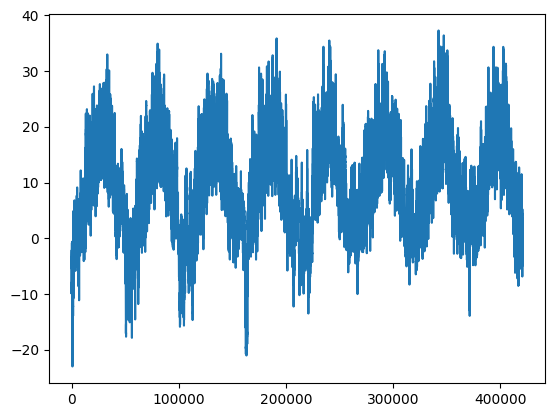

In [10]:
from matplotlib import pyplot as plt
plt.plot(range(len(temp)),temp)

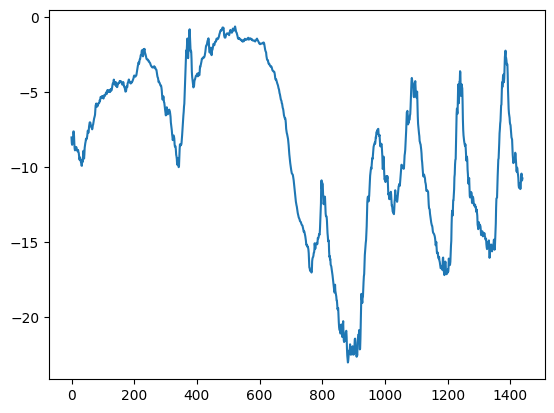

In [11]:
plt.plot(range(1440),temp[:1440])

In [12]:
raw_data.shape

(420551, 14)

In [13]:
num_train_samples = int(0.5 * len(raw_data))
num_val_samples = int(0.25 * len(raw_data))
num_test_samples = len(raw_data) - num_train_samples - num_val_samples

print("Number of sample for training: ", num_train_samples)
print("Number of sample for validation: ", num_val_samples)
print("Number of sample for test: ", num_test_samples)

Number of sample for training:  210275
Number of sample for validation:  105137
Number of sample for test:  105139


In [14]:
raw_data[:2]

array([[ 9.96520e+02, -8.02000e+00,  2.65400e+02, -8.90000e+00,
         9.33000e+01,  3.33000e+00,  3.11000e+00,  2.20000e-01,
         1.94000e+00,  3.12000e+00,  1.30775e+03,  1.03000e+00,
         1.75000e+00,  1.52300e+02],
       [ 9.96570e+02, -8.41000e+00,  2.65010e+02, -9.28000e+00,
         9.34000e+01,  3.23000e+00,  3.02000e+00,  2.10000e-01,
         1.89000e+00,  3.03000e+00,  1.30980e+03,  7.20000e-01,
         1.50000e+00,  1.36100e+02]])

In [15]:
mean = raw_data[:num_train_samples].mean(axis =0)
raw_data -= mean
std = raw_data[:num_train_samples].std(axis =0)
raw_data /= std

print(mean)
print(std)

[ 988.74889839    8.82544302  282.90464102    4.31273385   75.87140711
   13.14494034    9.19361693    3.95124803    5.81017534    9.30156034
 1218.45349561    2.14993523    3.56058809  176.44151735]
[ 8.50413655  8.76999279  8.86459576  7.07937329 16.62705297  7.60055179
  4.14654416  4.76906838  2.63254818  4.19932984 42.03438705  1.53360715
  2.32293276 85.84141633]


In [16]:
raw_data[:2]

array([[ 0.91380254, -1.92080466, -1.97466884, -1.86637055,  1.04820697,
        -1.29134576, -1.46715354, -0.7823851 , -1.47012517, -1.47203496,
         2.12436794, -0.73026213, -0.77944059, -0.28123391],
       [ 0.91968203, -1.96527448, -2.01866408, -1.92004762,  1.05422127,
        -1.3045027 , -1.48885836, -0.78448194, -1.48911818, -1.49346695,
         2.17313754, -0.93239995, -0.88706316, -0.469954  ]])

In [17]:
sampling_rate = 6
sequence_length = 120
delay = sampling_rate * (sequence_length +24 -1)
batch_size = 256

In [18]:
train_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temp[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples
)

val_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temp[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=False,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index= num_train_samples + num_val_samples
)
test_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[: -delay],
    targets = temp[delay:],
    sampling_rate = sampling_rate,
    sequence_length = sequence_length,
    shuffle = True,
    batch_size = batch_size,
    start_index = num_train_samples  + num_val_samples
)

In [19]:
print("TF version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))
print("CPU available:", tf.config.list_physical_devices('CPU'))

TF version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
CPU available: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [20]:
for samples, targets in train_dataset:
    print("Samples Shape: ",samples.shape)
    print("Targets Shape: ",targets.shape)
    break

Samples Shape:  (256, 120, 14)
Targets Shape:  (256,)


# Simple RNN

In [21]:

# Clear any previous models/layers
keras.backend.clear_session()

# Rebuild model fresh
num_features = raw_data.shape[-1]  # 14

inputs = keras.Input(shape=(int(sequence_length), int(num_features)))
x = keras.layers.Flatten()(inputs)
x = keras.layers.Dense(16, activation="relu")(x)
outputs = keras.layers.Dense(1)(x)

model = keras.Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 120, 14)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1680)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        26,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,913 (105.13 KB)

 Trainable params: 26,913 (105.13 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
callbacks = [
    keras.callbacks.ModelCheckpoint("jena_dense.keras", save_best_only = True)
]

model.compile(optimizer = "rmsprop", loss = "mse", metrics = ["mae"])

history = model.fit(
    train_dataset,
    epochs = 10,
    validation_data = val_dataset,
    callbacks = callbacks
)

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 40s 47ms/step - loss: 13.1759 - mae: 2.8061 - val_loss: 10.1759 - val_mae: 2.5244
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 38s 46ms/step - loss: 9.3553 - mae: 2.4052 - val_loss: 10.1569 - val_mae: 2.5201
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 38s 47ms/step - loss: 8.5912 - mae: 2.3091 - val_loss: 15.0030 - val_mae: 3.0840
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 39s 47ms/step - loss: 8.0583 - mae: 2.2391 - val_loss: 12.5187 - val_mae: 2.8135
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 39s 48ms/step - loss: 7.6637 - mae: 2.1865 - val_loss: 11.4235 - val_mae: 2.6961
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 38s 47ms/step - loss: 7.3867 - mae: 2.1486 - val_loss: 12.2151 - val_mae: 2.7903
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 40s 48ms/step - loss: 7.1608 - mae: 2.1161 - val_loss: 12.1275 - val_mae: 2.7691
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 38s 46ms/step - loss: 6.9778 - mae: 2.0905 - val_loss: 12.1810 - val_mae: 2.7757
Epoch 9/10
819/819 ━━━━━━━━━━━━

<function matplotlib.pyplot.show(close=None, block=None)>

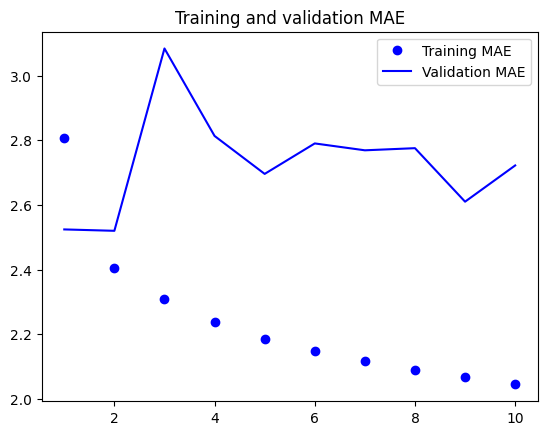

In [23]:
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label = "Training MAE")
plt.plot(epochs, val_loss, "b", label = "Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show

In [28]:
num_features = raw_data.shape[-1]  # 14

inputs = keras.Input(shape=(int(sequence_length), int(num_features)))
x = layers.Conv1D(8, 24, strides = 2, activation = "relu", padding="same")(inputs)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 12, strides = 2, activation = "relu", padding="same")(x)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 6, strides = 2, activation = "relu", padding="same")(x)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(1)(x)

model = keras.Model(inputs, outputs)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 120, 14)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 60, 8)          │         2,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 30, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 15, 8)          │           776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 7, 8)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 4, 8)           │           392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 8)              │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,873 (15.13 KB)

 Trainable params: 3,873 (15.13 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
callbacks = [
    keras.callbacks.ModelCheckpoint("jena_dense.keras", save_best_only = True)
]

model.compile(optimizer = "rmsprop", loss = "mse", metrics = ["mae"])

history = model.fit(
    train_dataset,
    epochs = 10,
    validation_data = val_dataset,
    callbacks = callbacks
)

model = keras.models.load_model("jena_dense.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 42s 47ms/step - loss: 18.4625 - mae: 3.2118 - val_loss: 10.1763 - val_mae: 2.4989
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 38s 46ms/step - loss: 9.9063 - mae: 2.4519 - val_loss: 9.7183 - val_mae: 2.4311
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 39s 47ms/step - loss: 8.9923 - mae: 2.3427 - val_loss: 9.8681 - val_mae: 2.4511
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 38s 47ms/step - loss: 8.6753 - mae: 2.3020 - val_loss: 9.9838 - val_mae: 2.4701
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 38s 46ms/step - loss: 8.4538 - mae: 2.2717 - val_loss: 10.3747 - val_mae: 2.5224
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 38s 46ms/step - loss: 8.2806 - mae: 2.2499 - val_loss: 10.1111 - val_mae: 2.4825
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 39s 48ms/step - loss: 8.1437 - mae: 2.2322 - val_loss: 10.8636 - val_mae: 2.5782
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 37s 45ms/step - loss: 8.0141 - mae: 2.2156 - val_loss: 10.4547 - val_mae: 2.5296
Epoch 9/10
819/819 ━━━━━━━━━━━━━━━

In [35]:
def plot_graph_mae(history):
  loss = history.history["mae"]
  val_loss = history.history["val_mae"]
  epochs = range(1, len(loss) + 1)
  plt.figure()
  plt.plot(epochs, loss, "bo", label = "Training MAE")
  plt.plot(epochs, val_loss, "b", label = "Validation MAE")
  plt.title("Training and validation MAE")
  plt.legend()
  plt.show()

# LSTM

In [30]:
num_features = raw_data.shape[-1]  # 14

inputs = keras.Input(shape=(int(sequence_length), int(num_features)))
x = layers.LSTM(16)(inputs)
outputs = layers.Dense(1)(x)

model = keras.Model(inputs, outputs)
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 120, 14)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 16)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,001 (7.82 KB)

 Trainable params: 2,001 (7.82 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
callbacks = [
    keras.callbacks.ModelCheckpoint("jena_dense.keras", save_best_only = True)
]

model.compile(optimizer = "rmsprop", loss = "mse", metrics = ["mae"])

history = model.fit(
    train_dataset,
    epochs = 10,
    validation_data = val_dataset,
    callbacks = callbacks
)

model = keras.models.load_model("jena_dense.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 52ms/step - loss: 39.8467 - mae: 4.5887 - val_loss: 12.5852 - val_mae: 2.7038
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 53ms/step - loss: 10.9761 - mae: 2.5859 - val_loss: 9.8610 - val_mae: 2.4378
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step - loss: 9.8958 - mae: 2.4611 - val_loss: 9.8630 - val_mae: 2.4429
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - loss: 9.4947 - mae: 2.4056 - val_loss: 9.6378 - val_mae: 2.4146
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 82s 51ms/step - loss: 9.2264 - mae: 2.3660 - val_loss: 9.8989 - val_mae: 2.4434
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 53ms/step - loss: 8.9860 - mae: 2.3334 - val_loss: 10.0299 - val_mae: 2.4455
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 83s 54ms/step - loss: 8.7572 - mae: 2.3041 - val_loss: 9.7991 - val_mae: 2.4255
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 82s 55ms/step - loss: 8.6000 - mae: 2.2836 - val_loss: 9.9613 - val_mae: 2.4566
Epoch 9/10
819/819 ━━━━━━━━━━━━━━━━━

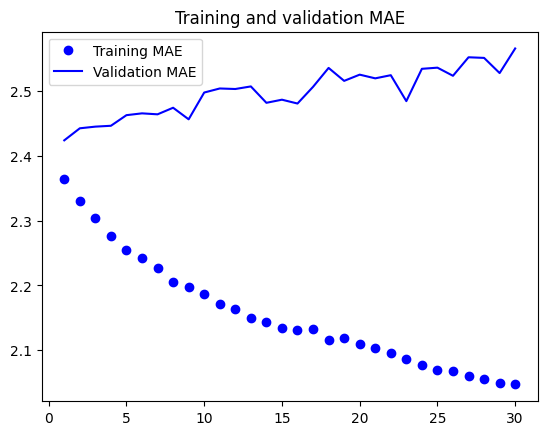

In [36]:
plot_graph_mae(history)

LSTM with Dropout to handle overfitting

In [ ]:
num_features = raw_data.shape[-1]  # 14

inputs = keras.Input(shape=(int(sequence_length), int(num_features)))
x = layers.LSTM(32, recurrent_dropout = 0.25)(inputs)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)

model = keras.Model(inputs, outputs)
model.summary()

In [33]:
callbacks = [
    keras.callbacks.ModelCheckpoint("jena_dense.keras", save_best_only = True)
]

model.compile(optimizer = "rmsprop", loss = "mse", metrics = ["mae"])

history = model.fit(
    train_dataset,
    epochs = 30,
    validation_data = val_dataset,
    callbacks = callbacks
)

model = keras.models.load_model("jena_lstm_dropout.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 49s 59ms/step - loss: 9.2161 - mae: 2.3647 - val_loss: 9.7662 - val_mae: 2.4241
Epoch 2/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 45s 55ms/step - loss: 8.9549 - mae: 2.3299 - val_loss: 9.9797 - val_mae: 2.4427
Epoch 3/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 48s 59ms/step - loss: 8.7566 - mae: 2.3034 - val_loss: 9.9325 - val_mae: 2.4453
Epoch 4/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 45s 55ms/step - loss: 8.5473 - mae: 2.2759 - val_loss: 9.9145 - val_mae: 2.4466
Epoch 5/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 45s 54ms/step - loss: 8.3744 - mae: 2.2543 - val_loss: 10.0893 - val_mae: 2.4630
Epoch 6/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 45s 54ms/step - loss: 8.2728 - mae: 2.2422 - val_loss: 10.0367 - val_mae: 2.4658
Epoch 7/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 52ms/step - loss: 8.1576 - mae: 2.2264 - val_loss: 10.0275 - val_mae: 2.4643
Epoch 8/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 54ms/step - loss: 8.0074 - mae: 2.2056 - val_loss: 10.0967 - val_mae: 2.4745
Epoch 9/30
819/819 ━━━━━━━━━━━━━━━━━

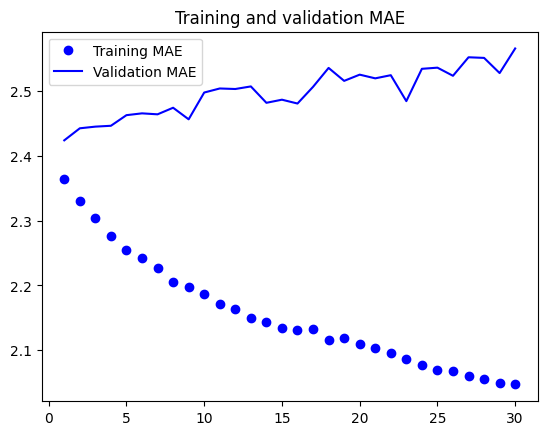

In [37]:
plot_graph_mae(history)

# GRU with Dropout Layer

In [38]:
num_features = raw_data.shape[-1]  # 14

inputs = keras.Input(shape=(int(sequence_length), int(num_features)))
x = layers.GRU(32, recurrent_dropout = 0.25, return_sequences = True)(inputs)
x = layers.GRU(32, recurrent_dropout = 0.25, return_sequences = True)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)

model = keras.Model(inputs, outputs)
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 120, 14)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 120, 32)        │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 120, 32)        │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 120, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 120, 1)         │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,977 (42.88 KB)

 Trainable params: 10,977 (42.88 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint("jena_dense.keras", save_best_only = True)
]

model.compile(optimizer = "adam", loss = "mse", metrics = ["mae"])

history = model.fit(
    train_dataset,
    epochs = 30,
    validation_data = val_dataset,
    callbacks = callbacks
)

model = keras.models.load_model("jena_gru_stack_dropout.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 613s 739ms/step - loss: 82.0507 - mae: 7.3212 - val_loss: 66.2957 - val_mae: 6.7023
Epoch 2/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 605s 738ms/step - loss: 78.5339 - mae: 7.1739 - val_loss: 66.1976 - val_mae: 6.6972
Epoch 3/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 604s 737ms/step - loss: 78.3560 - mae: 7.1665 - val_loss: 66.0857 - val_mae: 6.6913
Epoch 4/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 603s 736ms/step - loss: 78.2138 - mae: 7.1602 - val_loss: 66.1690 - val_mae: 6.6952
Epoch 5/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 592s 723ms/step - loss: 78.0691 - mae: 7.1541 - val_loss: 66.0244 - val_mae: 6.6873
Epoch 6/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 591s 722ms/step - loss: 77.9258 - mae: 7.1480 - val_loss: 66.1823 - val_mae: 6.6962
Epoch 7/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 591s 721ms/step - loss: 77.7992 - mae: 7.1426 - val_loss: 66.1646 - val_mae: 6.6931
Epoch 8/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 592s 723ms/step - loss: 77.6692 - mae: 7.1369 - val_loss: 65.9699 - val_mae: 6.6862
Epoch 9/

In [ ]:
plot_graph_mae(history)